<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Question 03**

Write your own function to equalize the histogram of an image. Apply this function to the runway image.

### Explanation:

1.  **`custom_histogram_equalization(image)` function:**
    *   **Grayscale Conversion:** It first ensures the input `image` is grayscale. If it's a color image (3 channels), it converts it to grayscale using `cv2.cvtColor`. Otherwise, it uses the image as is.
    *   **Histogram Calculation:** It calculates the histogram of the grayscale image using `np.histogram`. The `flatten()` method converts the 2D image array into a 1D array for histogram calculation.
    *   **Cumulative Distribution Function (CDF):** It then computes the cumulative sum of the histogram to get the CDF. This CDF represents the mapping from original pixel intensities to new intensities.
    *   **Normalization:** The CDF is normalized to the range [0, 255]. This is done by subtracting the minimum CDF value, dividing by the range (max CDF - min CDF), and multiplying by 255. This step scales the intensity values to fit within the standard 8-bit image range.
    *   **Lookup Table Creation:** The normalized CDF is rounded and cast to `uint8` to create a lookup table. This table directly maps each original pixel intensity to its new, equalized intensity.
    *   **Image Equalization:** Finally, it applies this lookup table to the original grayscale image. Each pixel's value in `gray_image` is used as an index into `lookup_table` to get its new value, resulting in the `equalized_image`.

2.  **Applying the function and Displaying Results:**
    *   **Load Image:** The `runway.png` image is loaded using `cv2.imread`.
    *   **Error Handling:** It checks if the image was loaded successfully.
    *   **Grayscale Conversion (for display):** The `original_image` is converted to grayscale to be displayed alongside the equalized image.
    *   **Apply Custom Function:** The `custom_histogram_equalization` function is called with the `original_image`.
    *   **Display:** `matplotlib.pyplot` is used to display both the `gray_image` (original grayscale) and the `equalized_image` side-by-side. Titles and axis labels are added for clarity, and `plt.tight_layout()` adjusts spacing to prevent overlap.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def custom_histogram_equalization(image):
    # Ensure the image is grayscale for simpler processing
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image

    # Calculate histogram
    hist, bins = np.histogram(gray_image.flatten(), 256, [0, 256])

    # Calculate cumulative distribution function (CDF)
    cdf = hist.cumsum()

    # Normalize CDF by subtracting min value and dividing by (max - min) * 255
    cdf_normalized = ((cdf - cdf.min()) * 255) / (cdf.max() - cdf.min())

    # Round to integer values and create a lookup table
    lookup_table = cdf_normalized.astype('uint8')

    # Apply the lookup table to the original grayscale image
    equalized_image = lookup_table[gray_image]

    return equalized_image

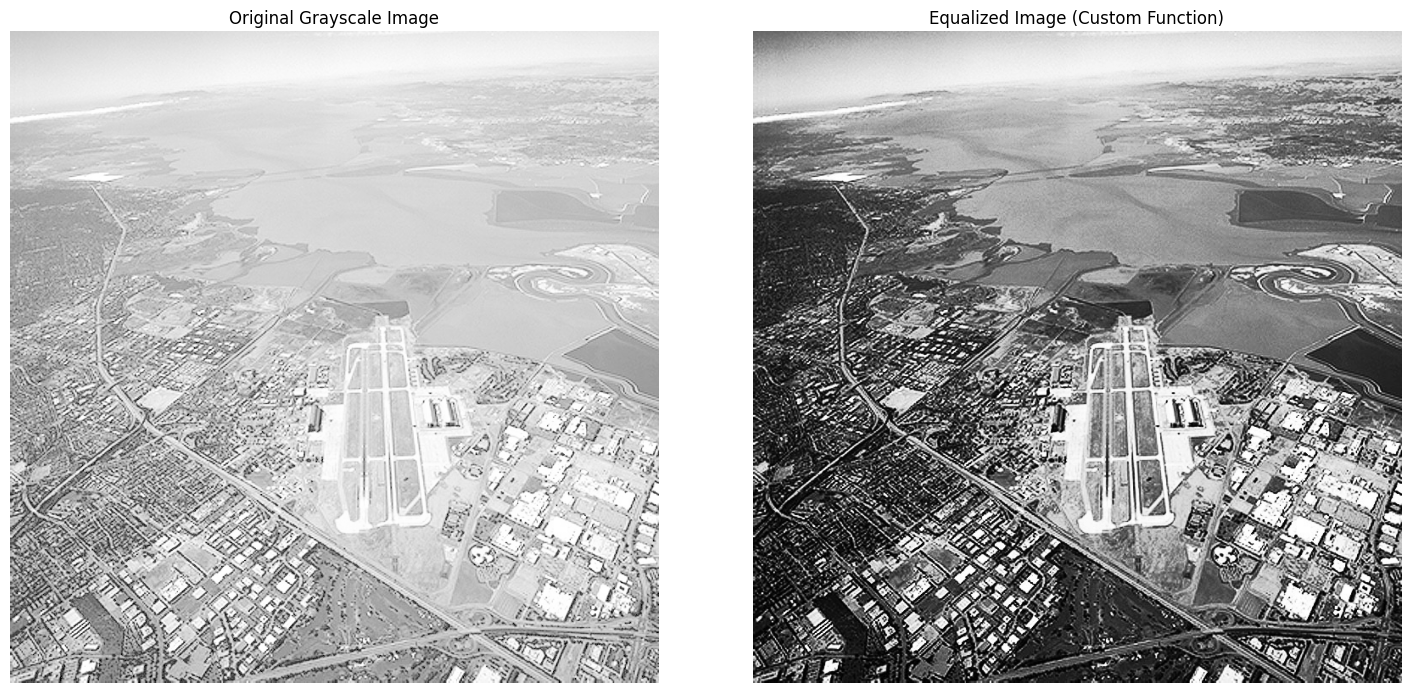

In [2]:
# Load the image
image_path = '/content/runway.png'
original_image = cv2.imread(image_path)

# Check if the image was loaded successfully
if original_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert to grayscale for histogram equalization
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    # Apply custom histogram equalization
    equalized_image = custom_histogram_equalization(original_image)

    # Display the original and equalized images
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(gray_image, cmap='gray')
    axes[0].set_title('Original Grayscale Image')
    axes[0].axis('off')

    axes[1].imshow(equalized_image, cmap='gray')
    axes[1].set_title('Equalized Image (Custom Function)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Summary: Histogram Equalization Process
Histogram equalization is a powerful image processing technique used to enhance the contrast of an image by redistributing its pixel intensities. The primary goal is to stretch the range of intensity values, making areas that were previously too dark or too bright more discernible.

The process works by analyzing the image's histogram, which represents the distribution of pixel intensities. It then constructs a cumulative distribution function (CDF) from this histogram. The key idea is to transform the original pixel values such that their new distribution in the output image is approximately uniform across the entire dynamic range (e.g., 0-255 for an 8-bit grayscale image).

This transformation effectively 'spreads out' the most frequent intensity values, leading to a more even distribution of brightness and a more visually appealing image with increased contrast. It is particularly effective for images with low contrast, where a large portion of the pixel values are concentrated within a narrow range.